In [55]:
%pip install psycopg2 sqlalchemy
%pip install pandas as pd
%pip install numpy as np
%pip install matplotlib.pyplot as plt
%pip install seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for as


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for as


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for matplotlib.pyplot


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for as


In [56]:
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

In [57]:
load_dotenv()  # Load environment variables from .env file

connection = psycopg2.connect(
    host=os.environ.get("DB_HOST", "localhost"),
    database=os.environ.get("DB_NAME", "postgres"),
    user=os.environ.get("DB_USER", "postgres"),
    password=os.environ.get("DB_PASSWORD"),
    port=os.environ.get("DB_PORT", "5432"),
)

In [58]:
query = "SELECT * FROM emailspam"
df = pd.read_sql_query(query, connection)

df

C:\Users\Faiz Akhmad Daulay\AppData\Local\Temp\ipykernel_2736\295722241.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


## Data Cleaning

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  5572 non-null   object
 1   message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [60]:
df.isna().sum()

category    0
message     0
dtype: int64

In [61]:
df.duplicated().sum()

415

In [62]:
df.drop_duplicates(inplace=True)

In [63]:
df.duplicated().sum()

0

## Explanatory Data Analysis

In [64]:
df

,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [65]:
df.describe()

,category,message
count,5157,5157
unique,2,5157
top,ham,"Go until jurong point, crazy.. Available only ..."
freq,4516,1


In [66]:
df['category'].value_counts()

category
ham     4516
spam     641
Name: count, dtype: int64

<Axes: xlabel='category'>

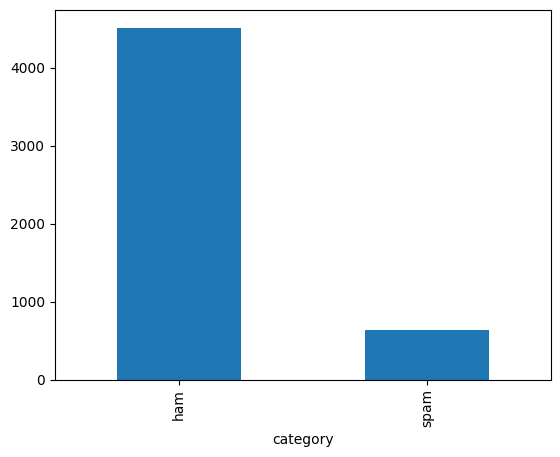

In [67]:
df['category'].value_counts().plot(kind='bar')

In [68]:
df['word_count'] = df['message'].apply(lambda x: len(str(x).split()))

In [69]:
df['char_count'] = df['message'].apply(lambda x: len(str(x)))

<Axes: title={'center': 'Word Count Distribution'}, ylabel='Frequency'>

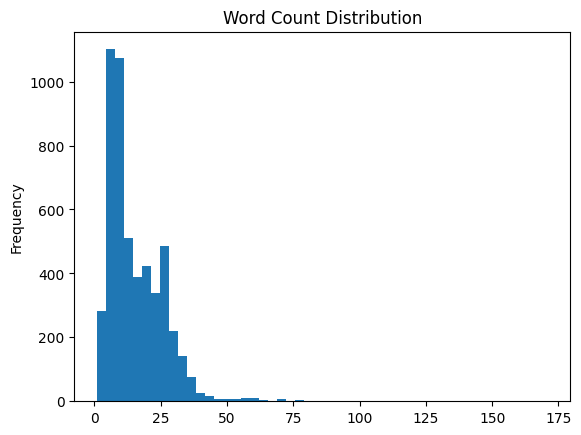

In [70]:
df['word_count'].plot(kind='hist', bins=50, title='Word Count Distribution')

In [71]:
df.groupby('category')['word_count'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
ham,4516.0,14.24,11.18,1.0,7.0,11.0,19.0,171.0
spam,641.0,23.66,6.04,1.0,21.0,25.0,28.0,35.0


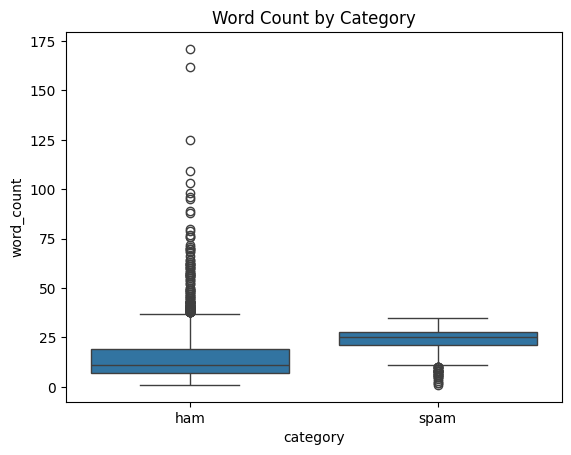

In [72]:
sns.boxplot(x='category', y='word_count', data=df)
plt.title('Word Count by Category')
plt.show()

In [73]:
df.groupby('category')['char_count'].mean()

category
ham      70.869353
spam    137.118565
Name: char_count, dtype: float64

C:\Users\Faiz Akhmad Daulay\AppData\Local\Temp\ipykernel_2736\2140788234.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='char_count', data=df, palette='Set2')


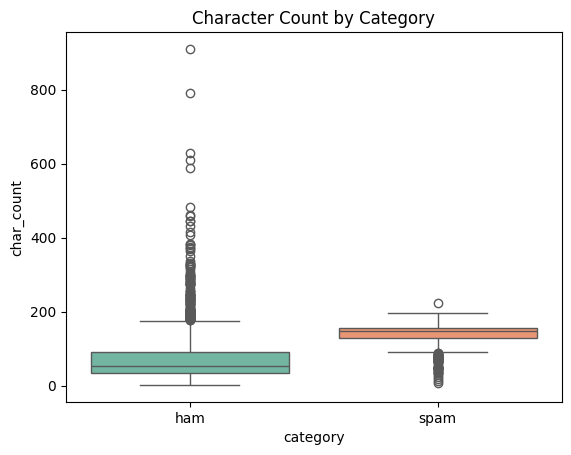

In [74]:
sns.boxplot(x='category', y='char_count', data=df, palette='Set2')
plt.title('Character Count by Category')
plt.show()

In [75]:
df.head(10)

,category,message,word_count,char_count
0,ham,"Go until jurong point, crazy.. Available only ...",20,111
1,ham,Ok lar... Joking wif u oni...,6,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28,155
3,ham,U dun say so early hor... U c already then say...,11,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",13,61
5,spam,FreeMsg Hey there darling it's been 3 week's n...,32,147
6,ham,Even my brother is not like to speak with me. ...,16,77
7,ham,As per your request 'Melle Melle (Oru Minnamin...,26,160
8,spam,WINNER!! As a valued network customer you have...,26,157
9,spam,Had your mobile 11 months or more? U R entitle...,29,154


## Data Preparation

In [76]:
%pip install sklearn
%pip install scipy
%pip install imblearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [77]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler, LabelEncoder
from scipy.sparse import hstack
from imblearn.over_sampling import SMOTE

In [122]:
x = df.iloc[:, 1:]
y = df['category']

In [79]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

In [80]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [81]:
X_train_text = tfidf.fit_transform(X_train['message'])
X_test_text = tfidf.transform(X_test['message'])

In [82]:
Scaler = RobustScaler()
X_train_numeric = Scaler.fit_transform(X_train[['word_count', 'char_count']])
X_test_numeric = Scaler.transform(X_test[['word_count', 'char_count']])

In [83]:
X_train_final = hstack([X_train_text, X_train_numeric])
X_text_final = hstack([X_test_text, X_test_numeric])

In [84]:
le = LabelEncoder()

y_train_coded = le.fit_transform(y_train)
y_test_coded = le.transform(y_test)

## Modeling

In [85]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [86]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

### XGBoost

In [87]:
xgb_model = XGBClassifier(n_estimators=200, max_depth=3, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_final, y_train_coded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [88]:
y_pred_xgb = xgb_model.predict(X_text_final)
print(classification_report(y_test_coded, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       904
           1       0.96      0.77      0.86       128

    accuracy                           0.97      1032
   macro avg       0.96      0.88      0.92      1032
weighted avg       0.97      0.97      0.97      1032



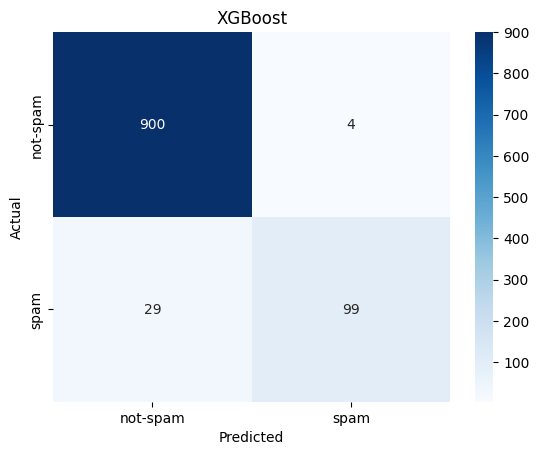

In [89]:
cm_xgb = confusion_matrix(y_test_coded, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['not-spam', 'spam'],
            yticklabels=['not-spam', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost')
plt.show()

### Linear Regression

In [90]:
LR_model = LogisticRegression(C=10, penalty='l2', solver='liblinear')
LR_model.fit(X_train_final, y_train_coded)

LogisticRegression(C=10, solver='liblinear')

In [91]:
y_pred_lr = LR_model.predict(X_text_final)
print(classification_report(y_test_coded, y_pred_lr))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       904
           1       0.95      0.84      0.89       128

    accuracy                           0.97      1032
   macro avg       0.96      0.92      0.94      1032
weighted avg       0.97      0.97      0.97      1032



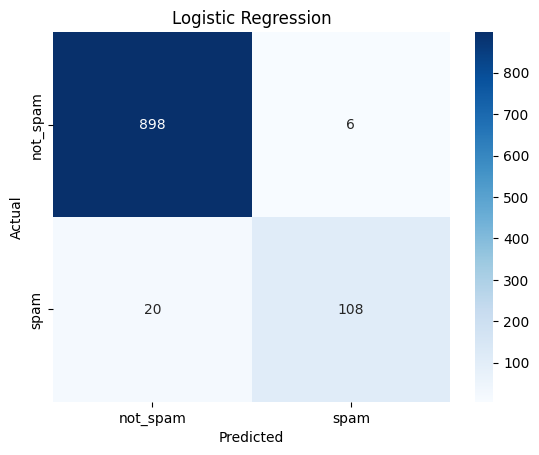

In [92]:
cm_lr = confusion_matrix(y_test_coded, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['not_spam', 'spam'],
            yticklabels=['not_spam', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression')
plt.show()

### Decision Tree

In [93]:
DT_model = DecisionTreeClassifier(criterion='entropy', splitter='best')
DT_model.fit(X_train_final, y_train_coded)

DecisionTreeClassifier(criterion='entropy')

In [94]:
y_pred_dt = DT_model.predict(X_text_final)
print(classification_report(y_test_coded, y_pred_dt))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       904
           1       0.86      0.77      0.81       128

    accuracy                           0.96      1032
   macro avg       0.91      0.87      0.89      1032
weighted avg       0.95      0.96      0.95      1032



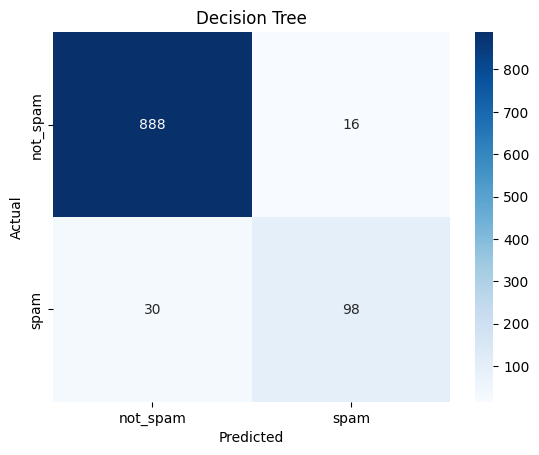

In [95]:
cm_dt = confusion_matrix(y_test_coded, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['not_spam', 'spam'],
            yticklabels=['not_spam', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree')
plt.show()

## Cross Validation

In [96]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [97]:
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=3000, stop_words='english',
                                  sublinear_tf=True, max_df=0.9, min_df=2), 'message'),
        ('num', RobustScaler(), ['char_count', 'word_count'])
    ]
)

In [98]:
models = {
    'XGBoost': Pipeline([
        ('prep', preprocessor),
        ('clf', XGBClassifier(n_estimators=200, max_depth=6, random_state=42, eval_metric='logloss'))
    ]),
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(max_iter=1000))
    ]),
    'Decision Tree': Pipeline([
        ('prep', preprocessor),
        ('clf', DecisionTreeClassifier(criterion='entropy'))
    ])
}

In [112]:
le1 = LabelEncoder()

y_encoded = le1.fit_transform(df['category'])

In [100]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define explicit feature matrix X using only the columns the preprocessor expects
X = df[['message', 'char_count', 'word_count']].copy()

for name, pipeline in models.items():
    # Pass X (features) and y_encoded (labels) separately. Set error_score='raise' to see failures.
    scores = cross_val_score(pipeline, df, y_encoded, cv=cv, scoring='f1_weighted', error_score='raise')
    print(f"{name}:")
    print(f"  F1 per fold : {np.round(scores, 4)}")
    print(f"  Mean F1     : {scores.mean():.4f}")
    print(f"  Std Dev     : {scores.std():.4f}\n")

XGBoost:
  F1 per fold : [0.9656 0.9638 0.9689 0.9721 0.9764]
  Mean F1     : 0.9693
  Std Dev     : 0.0045

Logistic Regression:
  F1 per fold : [0.9631 0.9592 0.9626 0.9718 0.9748]
  Mean F1     : 0.9663
  Std Dev     : 0.0060

Decision Tree:
  F1 per fold : [0.9466 0.9604 0.9568 0.946  0.9501]
  Mean F1     : 0.9520
  Std Dev     : 0.0057



## Using Smote

In [ ]:
# NewScaler = RobustScaler()
# Newtfidf = TfidfVectorizer(max_features=3000, stop_words='english')

# x_num = NewScaler.fit_transform(x[['word_count', 'char_count']])
# x_text = Newtfidf.fit_transform(x[['message']])

# x_text = Newtfidf.fit_transform(x['message'].astype(str))
# x = hstack([x_text, x_num])

In [107]:
y_encoded = y.map({
    'ham' : 0,
    'spam' : 1
})

In [123]:
smote = SMOTE()

X_rev, y_rev = smote.fit_resample(x, y_encoded)

print("="*30)
# print(y_rev.value_counts())

ValueError: could not convert string to float: 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [118]:

print(type(x))
print(getattr(x, "columns", None))

<class 'scipy.sparse._coo.coo_matrix'>
None


In [120]:
for name, pipeline in models.items():
    # Pass X (features) and y_encoded (labels) separately. Set error_score='raise' to see failures.
    scores = cross_val_score(pipeline, x, y_encoded, cv=cv, scoring='f1_weighted', error_score='raise')
    print(f"{name}:")
    print(f"  F1 per fold : {np.round(scores, 4)}")
    print(f"  Mean F1     : {scores.mean():.4f}")
    print(f"  Std Dev     : {scores.std():.4f}\n")

ValueError: Specifying the columns using strings is only supported for dataframes.